판다스의 데이터 구조 : 시리즈와 데이터프레임

시리즈

In [7]:
!pip install pandas

In [1]:
import numpy as np
import pandas as pd
series = pd.Series([1, 3, 4, np.nan, 6, 8])
series

0    1.0
1    3.0
2    4.0
3    NaN
4    6.0
5    8.0
dtype: float64

데이터프레임

In [2]:
name_series = pd.Series(['김수안', '김수정', '박동윤', '강이안', '강지안'])
age_series = pd.Series([19, 23, 22, 19, 16])
gender_series = pd.Series(['여', '여', '남', '여', '남'])
grade_series = pd.Series([4.35, 4.23, 4.25, 4.37, 4.25])
print(name_series, age_series, gender_series, grade_series)

0    김수안
1    김수정
2    박동윤
3    강이안
4    강지안
dtype: object 0    19
1    23
2    22
3    19
4    16
dtype: int64 0    여
1    여
2    남
3    여
4    남
dtype: object 0    4.35
1    4.23
2    4.25
3    4.37
4    4.25
dtype: float64


In [3]:
df = pd.DataFrame({'이름': name_series, '나이': age_series,
                   '성별': gender_series, '평점': grade_series})
print(df)

    이름  나이 성별    평점
0  김수안  19  여  4.35
1  김수정  23  여  4.23
2  박동윤  22  남  4.25
3  강이안  19  여  4.37
4  강지안  16  남  4.25


판다스로 데이터 파일을 읽기

https://github.com/dongupak/DataSciPy/blob/master/data/csv/countries.csv

In [4]:
import pandas as pd
df = pd.read_csv('countries.csv')

In [5]:
df

,Unnamed: 0,country,area,capital,population
0,KR,Korea,98480,Seoul,51780579
1,US,USA,9629091,Washington,331002825
2,JP,Japan,377835,Tokyo,125960000
3,CN,China,9596960,Beijing,1439323688
4,RU,Russia,17100000,Moscow,146748600


#### 데이터를 설명하는 인덱스와 컬럼스 객체

In [6]:
import pandas as pd 

df = pd.read_csv('countries.csv', index_col = 0)    # 첫 열을 인덱스 컬럼으로 사용
print(df)

   country      area     capital  population
KR   Korea     98480       Seoul    51780579
US     USA   9629091  Washington   331002825
JP   Japan    377835       Tokyo   125960000
CN   China   9596960     Beijing  1439323688
RU  Russia  17100000      Moscow   146748600


### 12.6 열을 기준으로 데이터 선택하기

In [7]:
import pandas as pd 

df_my_index = pd.read_csv('countries.csv', index_col = 0)
df_no_index = pd.read_csv('countries.csv')
print(df_my_index['population'])
print(df_no_index['population'])

KR      51780579
US     331002825
JP     125960000
CN    1439323688
RU     146748600
Name: population, dtype: int64
0      51780579
1     331002825
2     125960000
3    1439323688
4     146748600
Name: population, dtype: int64


In [8]:
import pandas as pd 

df_my_index = pd.read_csv('countries.csv', index_col = 0)
print(df_my_index[['area', 'population']])

        area  population
KR     98480    51780579
US   9629091   331002825
JP    377835   125960000
CN   9596960  1439323688
RU  17100000   146748600


슬라이싱으로 행 선택하기

In [9]:
countries_df = pd.read_csv('countries.csv', index_col = 0)

In [10]:
countries_df.head()     # countries_df[0:5]와 같다

,country,area,capital,population
KR,Korea,98480,Seoul,51780579
US,USA,9629091,Washington,331002825
JP,Japan,377835,Tokyo,125960000
CN,China,9596960,Beijing,1439323688
RU,Russia,17100000,Moscow,146748600


In [11]:
countries_df[:3]

,country,area,capital,population
KR,Korea,98480,Seoul,51780579
US,USA,9629091,Washington,331002825
JP,Japan,377835,Tokyo,125960000


In [19]:
countries_df.loc['KR']

country          Korea
area             98480
capital          Seoul
population    51780579
Name: KR, dtype: object

In [20]:
countries_df['population'][:3]

KR     51780579
US    331002825
JP    125960000
Name: population, dtype: int64

In [21]:
countries_df.loc['US', 'capital']

'Washington'

In [22]:
countries_df['capital'].loc['US']

'Washington'

#### 새로운 열을 생성해 보자

In [12]:
import pandas as pd

countries_df = pd.read_csv('countries.csv', index_col = 0)
countries_df['density'] = countries_df['population'] / countries_df['area']
print(countries_df)

   country      area     capital  population     density
KR   Korea     98480       Seoul    51780579  525.797918
US     USA   9629091  Washington   331002825   34.375293
JP   Japan    377835       Tokyo   125960000  333.373033
CN   China   9596960     Beijing  1439323688  149.977044
RU  Russia  17100000      Moscow   146748600    8.581789


### 12.8 데이터를 간편하게 분석할 수 있는 기능이 있다

In [13]:
import pandas as pd
weather = pd.read_csv('weather.csv', index_col = 0, encoding='CP949')

print(weather.describe())

              평균기온         최대풍속         평균풍속
count  3653.000000  3649.000000  3647.000000
mean     12.942102     7.911099     3.936441
std       8.538507     3.029862     1.888473
min      -9.000000     2.000000     0.200000
25%       5.400000     5.700000     2.500000
50%      13.800000     7.600000     3.600000
75%      20.100000     9.700000     5.000000
max      31.300000    26.000000    14.900000


In [14]:
print('평균 분석 -----------------------------')
print(weather.mean())
print('표준편차  분석 -----------------------------')
print(weather.std())

평균 분석 -----------------------------
평균기온    12.942102
최대풍속     7.911099
평균풍속     3.936441
dtype: float64
표준편차  분석 -----------------------------
평균기온    8.538507
최대풍속    3.029862
평균풍속    1.888473
dtype: float64


#### 데이터 집계 분석도 쉽게 해 보자

In [15]:
weather = pd.read_csv('weather.csv', index_col = 0, encoding='CP949')  
weather.count()     # 각 열의 데이터 수를 알려준다

평균기온    3653
최대풍속    3649
평균풍속    3647
dtype: int64

In [16]:
weather['최대풍속'].count()              # '최대풍속' 열의 데이터 수를 알려준다

3649

In [17]:
weather[['최대풍속','평균풍속']].count()    # '최대풍속', '평균풍속' 열의 데이터 수

최대풍속    3649
평균풍속    3647
dtype: int64

In [18]:
weather[['최대풍속','평균풍속']].mean()     # '최대풍속', '평균풍속' 열의 평균값

최대풍속    7.911099
평균풍속    3.936441
dtype: float64

In [19]:
weather.mean()[['최대풍속', '평균풍속']]

최대풍속    7.911099
평균풍속    3.936441
dtype: float64

### 12.9 연도와 월, 일을 다루는 DatetimeIndex와 그룹핑

In [20]:
import  pandas as pd
# DatetimeIndex를 이용하여 연도를 추출 
print(pd.DatetimeIndex(['2010-08-01', '2011-09-21']).year)

Index([2010, 2011], dtype='int32')


In [21]:
# DatetimeIndex를 이용하여 월을 추출 
print(pd.DatetimeIndex(['2010-08-01', '2011-09-21']).month)

Index([8, 9], dtype='int32')


In [22]:
# DatetimeIndex를 이용하여 일을 추출 
print(pd.DatetimeIndex(['2010-08-01', '2011-09-21']).day)

Index([1, 21], dtype='int32')


In [23]:
weather = pd.read_csv('weather.csv', encoding='CP949')
weather['month'] = pd.DatetimeIndex(weather['일시']).month  # 새로운 'month' 열을 만든다 
print(weather)

              일시  평균기온  최대풍속  평균풍속  month
0     2010-08-01  28.7   8.3   3.4      8
1     2010-08-02  25.2   8.7   3.8      8
2     2010-08-03  22.1   6.3   2.9      8
3     2010-08-04  25.3   6.6   4.2      8
4     2010-08-05  27.2   9.1   5.6      8
...          ...   ...   ...   ...    ...
3648  2020-07-27  22.1   4.2   1.7      7
3649  2020-07-28  21.9   4.5   1.6      7
3650  2020-07-29  21.6   3.2   1.0      7
3651  2020-07-30  22.9   9.7   2.4      7
3652  2020-07-31  25.7   4.8   2.5      7

[3653 rows x 5 columns]


In [24]:
# numeric_only = True라는 키워드 인자를 통해서 일시 열을 계산에서 제외시키도록 한다
means = weather.groupby('month').mean(numeric_only = True)  # 'month'를 기준으로 묶고 평균을 구함

print(means) # 그룹으로 묶인 'month' 데이터를 기준으로 평균값을 출력한다

            평균기온      최대풍속      평균풍속
month                               
1       1.598387  8.158065  3.757419
2       2.136396  8.225357  3.946786
3       6.250323  8.871935  4.390291
4      11.064667  9.305017  4.622483
5      16.564194  8.548710  4.219355
6      19.616667  6.945667  3.461000
7      23.328387  7.322581  3.877419
8      24.748710  6.853226  3.596129
9      20.323667  6.896333  3.661667
10     15.383871  7.766774  3.961613
11      9.889667  8.013333  3.930667
12      3.753548  8.045484  3.817097


### 12.10 데이터를 특정한 값에 기반하여 묶는 기능 : 그룹핑

In [25]:
weather = pd.read_csv('weather.csv', encoding='CP949')
weather['year'] = pd.DatetimeIndex(weather['일시']).year    # 새로운 'year' 열을 만든다 
print(weather)

              일시  평균기온  최대풍속  평균풍속  year
0     2010-08-01  28.7   8.3   3.4  2010
1     2010-08-02  25.2   8.7   3.8  2010
2     2010-08-03  22.1   6.3   2.9  2010
3     2010-08-04  25.3   6.6   4.2  2010
4     2010-08-05  27.2   9.1   5.6  2010
...          ...   ...   ...   ...   ...
3648  2020-07-27  22.1   4.2   1.7  2020
3649  2020-07-28  21.9   4.5   1.6  2020
3650  2020-07-29  21.6   3.2   1.0  2020
3651  2020-07-30  22.9   9.7   2.4  2020
3652  2020-07-31  25.7   4.8   2.5  2020

[3653 rows x 5 columns]


In [37]:
y_means = weather.groupby('year').mean(numeric_only=True) 
print(y_means)

           평균기온      최대풍속      평균풍속
year                               
2010  15.238562  8.205229  4.069281
2011  12.073425  8.355616  4.251233
2012  11.892896  7.794490  3.863912
2013  12.795068  7.859726  3.874795
2014  12.844110  7.458904  3.816438
2015  13.162466  7.694247  3.799449
2016  13.243443  7.963934  3.977869
2017  13.111233  8.001370  3.934795
2018  13.041644  8.158630  4.085479
2019  13.767671  7.796703  3.854396
2020  12.233333  7.897183  3.786385


In [38]:
y_max = weather.groupby('year').max(numeric_only=True) 
print(y_max)

      평균기온  최대풍속  평균풍속
year                  
2010  28.9  16.9  10.3
2011  27.6  21.6  12.5
2012  28.3  17.5   9.2
2013  31.3  17.8  10.1
2014  27.5  16.1  11.2
2015  29.6  25.3  14.9
2016  28.5  18.0  13.3
2017  28.3  18.0  12.7
2018  30.5  26.0  12.0
2019  29.7  25.8  12.7
2020  25.7  22.2  11.6


### LAB 12-2 울릉도는 몇 월에 바람이 가장 강할까? - groupby() 활용

In [42]:
!pip install matplotlib

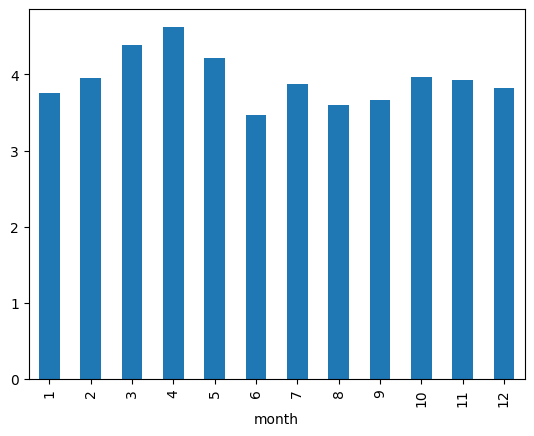

In [43]:
import pandas as pd
import matplotlib.pyplot as plt 
import datetime as dt

weather = pd.read_csv('weather.csv', encoding='CP949')

weather['month'] = pd.DatetimeIndex(weather['일시']).month 
means = weather.groupby('month').mean(numeric_only = True) 
means['평균풍속'].plot(kind = 'bar')

plt.show()

### 12.11 조건에 맞게 골라내자 : 필터링

In [44]:
weather['최대풍속'] >= 10.0

0       False
1       False
2       False
3       False
4       False
        ...  
3648    False
3649    False
3650    False
3651    False
3652    False
Name: 최대풍속, Length: 3653, dtype: bool

In [45]:
weather[ weather['최대풍속'] >= 10.0 ]

,일시,평균기온,최대풍속,평균풍속,month
9,2010-08-10,25.6,10.2,5.5,8
12,2010-08-13,24.3,10.9,4.6,8
13,2010-08-14,25.0,10.8,4.4,8
14,2010-08-15,24.5,16.9,10.3,8
29,2010-08-30,26.2,10.5,6.2,8
...,...,...,...,...,...
3622,2020-07-01,16.8,19.7,8.7,7
3632,2020-07-11,20.1,10.3,4.1,7
3634,2020-07-13,17.8,10.3,4.6,7
3635,2020-07-14,17.8,12.7,9.4,7


#### 빠진 값을 찾고 삭제하기

In [46]:
weather['평균풍속'].isna()

0       False
1       False
2       False
3       False
4       False
        ...  
3648    False
3649    False
3650    False
3651    False
3652    False
Name: 평균풍속, Length: 3653, dtype: bool

In [47]:
import pandas as pd

weather = pd.read_csv('weather.csv', index_col = 0, encoding='CP949') 
missing_data = weather [ weather['평균풍속'].isna() ]
print(missing_data)

            평균기온  최대풍속  평균풍속
일시                          
2012-02-11  -0.7   NaN   NaN
2012-02-12   0.4   NaN   NaN
2012-02-13   4.0   NaN   NaN
2015-03-22  10.1  11.6   NaN
2015-04-01   7.3  12.1   NaN
2019-04-18  15.7  11.7   NaN


In [48]:
weather.dropna(axis=0, how="any", inplace=True)
weather.loc['2012-02-11']  # 2012년 2월 11일 데이터가 삭제되어 오류발생

KeyError: '2012-02-11'

### 12.12 빠진 데이터를 깨끗하게 메워 보자

In [50]:
import pandas as pd

weather = pd.read_csv('weather.csv', index_col = 0, encoding='CP949') 
weather.fillna(0, inplace = True)   # 결손값을 0으로 채움, inplace를 True로 설정해 원본 데이터를 수정 

print(weather.loc['2012-02-11'])    # 2012년 2월 11일 데이터가 삭제되지 않음

평균기온   -0.7
최대풍속    0.0
평균풍속    0.0
Name: 2012-02-11, dtype: float64


In [51]:
weather.fillna( weather['평균풍속'].mean(), inplace = True) 
print(weather.loc['2012-02-11'])    # 2012년 2월 11일 데이터가 삭제되지 않음

평균기온   -0.7
최대풍속    0.0
평균풍속    0.0
Name: 2012-02-11, dtype: float64


#### 데이터를 크기에 따라 나열하자 : 정렬

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

countries_df = pd.read_csv('countries.csv', index_col = 0)
sorted_df = countries_df.sort_values('population')  # 인구 수(population)의 오름차순 정렬 
print(sorted_df)

   country      area     capital  population
KR   Korea     98480       Seoul    51780579
JP   Japan    377835       Tokyo   125960000
RU  Russia  17100000      Moscow   146748600
US     USA   9629091  Washington   331002825
CN   China   9596960     Beijing  1439323688


In [55]:
countries_df = pd.read_csv('countries.csv', index_col = 0) 
countries_df.sort_values('population', inplace = True) 
print(countries_df)

   country      area     capital  population
KR   Korea     98480       Seoul    51780579
JP   Japan    377835       Tokyo   125960000
RU  Russia  17100000      Moscow   146748600
US     USA   9629091  Washington   331002825
CN   China   9596960     Beijing  1439323688


In [ ]:
countries = pd.read_csv('countries.csv', index_col = 0, encoding='CP949') 
countries.sort_values(['population', 'area'], ascending = False, inplace = True) 
print(countries)

FileNotFoundError: [Errno 2] No such file or directory: 'd:/data/countries.csv'

### 12.13 데이터 구조를 변경해 보자

In [ ]:
df_1 = pd.DataFrame({'item' : ['ring0', 'ring0', 'ring1', 'ring1'], 
                     'type' : ['Gold', 'Silver', 'Gold', 'Bronze'], 
                     'price': [20000, 10000, 50000, 30000]})
print(df_1)

    item    type  price
0  ring0    Gold  20000
1  ring0  Silver  10000
2  ring1    Gold  50000
3  ring1  Bronze  30000


In [ ]:
df_2 = df_1.pivot(index='item', columns='type', values='price') 
print(df_2)

type    Bronze     Gold   Silver
item                            
ring0      NaN  20000.0  10000.0
ring1  30000.0  50000.0      NaN


#### concat() 함수로 데이터프레임을 합쳐보자

In [ ]:
df_1 = pd.DataFrame( {'A' : ['a10', 'a11', 'a12'], 
                      'B' : ['b10', 'b11', 'b12'],
                      'C' : ['c10', 'c11', 'c12']} , index = ['가', '나',  '다'] )

df_2 = pd.DataFrame( {'B' : ['b23', 'b24', 'b25'],
                      'C' : ['c23', 'c24', 'c25'],
                      'D' : ['d23', 'd24', 'd25']} , index = ['다', '라',  '마'] )

In [ ]:
df_3 = pd.concat( [df_1, df_2] )    # df_1, df_2 두 데이터프레임을 합쳐서 df_3을 생성
print(df_3)

     A    B    C    D
가  a10  b10  c10  NaN
나  a11  b11  c11  NaN
다  a12  b12  c12  NaN
다  NaN  b23  c23  d23
라  NaN  b24  c24  d24
마  NaN  b25  c25  d25


### LAB 12-3 다양한 방법으로 concat 적용해 보기

In [ ]:
import pandas as pd 

df_1 = pd.DataFrame( 
            {'A' : ['a10', 'a11', 'a12'], 
             'B' : ['b10', 'b11', 'b12'],
             'C' : ['c10', 'c11', 'c12']} , index = ['가', '나',  '다'] )

df_2 = pd.DataFrame( 
            {'B' : ['b23', 'b24', 'b25'],
             'C' : ['c23', 'c24', 'c25'],
             'D' : ['d23', 'd24', 'd25']} , index = ['다', '라',  '마'] )


print( pd.concat( [df_1, df_2] , axis = 0, join = 'outer' ) ) 
print( pd.concat( [df_1, df_2] , axis = 0, join = 'inner' ) ) 
print( pd.concat( [df_1, df_2] , axis = 1, join = 'outer' ) ) 
print( pd.concat( [df_1, df_2] , axis = 1, join = 'inner' ) )

     A    B    C    D
가  a10  b10  c10  NaN
나  a11  b11  c11  NaN
다  a12  b12  c12  NaN
다  NaN  b23  c23  d23
라  NaN  b24  c24  d24
마  NaN  b25  c25  d25
     B    C
가  b10  c10
나  b11  c11
다  b12  c12
다  b23  c23
라  b24  c24
마  b25  c25
     A    B    C    B    C    D
가  a10  b10  c10  NaN  NaN  NaN
나  a11  b11  c11  NaN  NaN  NaN
다  a12  b12  c12  b23  c23  d23
라  NaN  NaN  NaN  b24  c24  d24
마  NaN  NaN  NaN  b25  c25  d25
     A    B    C    B    C    D
다  a12  b12  c12  b23  c23  d23


### 12.14 데이터베이스 join 방식의 데이터 병합 - merge

In [ ]:
df_3 = df_1.merge(df_2, how='outer', on='B')
print(df_3)

     A    B  C_x  C_y    D
0  a10  b10  c10  NaN  NaN
1  a11  b11  c11  NaN  NaN
2  a12  b12  c12  NaN  NaN
3  NaN  b23  NaN  c23  d23
4  NaN  b24  NaN  c24  d24
5  NaN  b25  NaN  c25  d25


#### 인덱스를 키로 활용하여 merge 적용해 보기

In [ ]:
df_1.merge(df_2, how = 'outer', left_index = True, right_index = True )

,A,B_x,C_x,B_y,C_y,D
가,a10,b10,c10,NaN,NaN,NaN
나,a11,b11,c11,NaN,NaN,NaN
다,a12,b12,c12,b23,c23,d23
라,NaN,NaN,NaN,b24,c24,d24
마,NaN,NaN,NaN,b25,c25,d25


In [ ]:
df_3 = df_1.merge(df_2, how='outer', left_index = True, right_index = True )
print(df_3)

     A  B_x  C_x  B_y  C_y    D
가  a10  b10  c10  NaN  NaN  NaN
나  a11  b11  c11  NaN  NaN  NaN
다  a12  b12  c12  b23  c23  d23
라  NaN  NaN  NaN  b24  c24  d24
마  NaN  NaN  NaN  b25  c25  d25


### LAB 12-4 다양한 방법으로 merge 적용해 보기

In [ ]:
import pandas as pd

df_1 = pd.DataFrame( {'A' : ['a10', 'a11', 'a12'], 
                      'B' : ['b10', 'b11', 'b12'],
                      'C' : ['c10', 'c11', 'c12']} , index = ['가', '나', '다'] )

df_2 = pd.DataFrame( {'B' : ['b23', 'b24', 'b25'], 
                      'C' : ['c23', 'c24', 'c25'],
                      'D' : ['d23', 'd24', 'd25']} , index = ['다', '라', '마'] )

print('left outer \n' , df_1.merge(df_2, how='left', on='B' ) ) 
print('right outer \n' ,df_1.merge(df_2, how='right', on='B' ) ) 
print('full outer \n' ,df_1.merge(df_2, how='outer', on='B' ) ) 
print('inner \n' ,df_1.merge(df_2, how='inner', on='B' ) )

left outer 
      A    B  C_x  C_y    D
0  a10  b10  c10  NaN  NaN
1  a11  b11  c11  NaN  NaN
2  a12  b12  c12  NaN  NaN
right outer 
      A    B  C_x  C_y    D
0  NaN  b23  NaN  c23  d23
1  NaN  b24  NaN  c24  d24
2  NaN  b25  NaN  c25  d25
full outer 
      A    B  C_x  C_y    D
0  a10  b10  c10  NaN  NaN
1  a11  b11  c11  NaN  NaN
2  a12  b12  c12  NaN  NaN
3  NaN  b23  NaN  c23  d23
4  NaN  b24  NaN  c24  d24
5  NaN  b25  NaN  c25  d25
inner 
 Empty DataFrame
Columns: [A, B, C_x, C_y, D]
Index: []
